<a href="https://colab.research.google.com/github/mfernandezzz/Pruebas_Tecnicas/blob/main/TT_social_media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/social_media_mental_health.csv')
pd.set_option('display.max_columns', None)

In [ ]:
df.shape

(8000, 15)

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

In [ ]:
# for c in df.select_dtypes('object'):
#  df[c] = df[c].astype('category')

In [ ]:
for i in df.select_dtypes('integer'):
  df[i] = pd.to_numeric(df[i], downcast='integer')

In [ ]:
for f in df.select_dtypes('float'):
  df[f] = pd.to_numeric(df[f], downcast='float')

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int8   
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float32
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int8   
 9   Social_Comparison_Trigger  8000 non-null   int8   
 10  Sleep_Duration_Hours       8000 non-null   float32
 11  GAD_7_Score                8000 non-null   int8   
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int8 

In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)
df.columns

Index(['user_id', 'age', 'gender', 'user_archetype', 'primary_platform',
       'daily_screen_time_hours', 'dominant_content_type', 'activity_type',
       'late_night_usage', 'social_comparison_trigger', 'sleep_duration_hours',
       'gad_7_score', 'gad_7_severity', 'phq_9_score', 'phq_9_severity'],
      dtype='object')

In [ ]:
nulls_count = df.isnull().sum()
nulls_count[nulls_count > 0].sort_values(ascending=False)

,0


In [ ]:
nulls_percentage = df.isnull().mean()*100
nulls_percentage[nulls_percentage > 0].sort_values(ascending=False)

,0


In [ ]:
duplicates_sum = df.duplicated().sum()
duplicates_sum

np.int64(0)

In [ ]:
duplicates_percentage = (df.duplicated().sum()/df.shape[0]) * 100
duplicates_percentage

np.float64(0.0)

In [ ]:
# show_duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head()
# show_duplicates

In [ ]:
# df = df.drop_duplicates()

**¿Con que edad se consumen mas las redes sociales?**

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'user_archetype', 'primary_platform',
       'daily_screen_time_hours', 'dominant_content_type', 'activity_type',
       'late_night_usage', 'social_comparison_trigger', 'sleep_duration_hours',
       'gad_7_score', 'gad_7_severity', 'phq_9_score', 'phq_9_severity'],
      dtype='object')

In [ ]:
df.head()

,user_id,age,gender,user_archetype,primary_platform,daily_screen_time_hours,dominant_content_type,activity_type,late_night_usage,social_comparison_trigger,sleep_duration_hours,gad_7_score,gad_7_severity,phq_9_score,phq_9_severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [ ]:
df['age'].unique()

array([18, 20, 21, 19, 22], dtype=int8)

In [ ]:
df['age'].value_counts()

,count
age,
18,3166
19,2415
20,1613
22,404
21,402


In [ ]:
df['daily_screen_time_hours'].dtype

dtype('float32')

In [ ]:
hours = df.groupby('age')['daily_screen_time_hours'].mean()
hours

,daily_screen_time_hours
age,
18,4.251766
19,4.301255
20,4.296683
21,4.129801
22,4.401807


In [ ]:
age = df.groupby('age')['daily_screen_time_hours'].mean().idxmax()
age

np.int8(22)

In [ ]:
print(f'Edad con mayor consumo de Redes Sociales entre los encuestados: {age} años.')
print(f'Cantidad de horas promedio que el grupo de {age} años cosume Redes Sociales por dia: {round(hours.max(), 1)} horas.')

Edad con mayor consumo de Redes Sociales entre los encuestados: 22 años.
Cantidad de horas promedio que el grupo de 22 años cosume Redes Sociales por dia: 4.4 horas.


**Obtener la edad con la que se consume mas cada Red Social y su consumo diario asociado.**

In [ ]:
df.head()

,user_id,age,gender,user_archetype,primary_platform,daily_screen_time_hours,dominant_content_type,activity_type,late_night_usage,social_comparison_trigger,sleep_duration_hours,gad_7_score,gad_7_severity,phq_9_score,phq_9_severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [ ]:
df_socials = df.groupby(['primary_platform', 'age'])['daily_screen_time_hours'].mean().round(1).reset_index()
df_socials.head()

,primary_platform,age,daily_screen_time_hours
0,Facebook,18,4.3
1,Facebook,19,4.3
2,Facebook,20,4.5
3,Facebook,21,4.0
4,Facebook,22,4.1


In [ ]:
idx = df_socials.groupby('primary_platform')['daily_screen_time_hours'].idxmax()
max_usage_by_platform = df_socials.loc[idx]
display(max_usage_by_platform)

,primary_platform,age,daily_screen_time_hours
2,Facebook,20,4.5
9,Instagram,22,5.3
11,LinkedIn,19,4.3
16,Snapchat,19,4.5
24,TikTok,22,4.8
29,Twitter/X,22,4.7
33,YouTube,21,4.5


**Agrupar el arquetipo con la cantidad de uso diario promedio y la edad asociada.**

In [ ]:
df['user_archetype'].unique()

array(['Hyper-Connected', 'Digital Minimalist', 'Passive Scroller',
       'Average User'], dtype=object)

In [ ]:
df_archetypes = df.groupby(['user_archetype', 'age'])['daily_screen_time_hours'].mean().round(1).reset_index()
df_archetypes

,user_archetype,age,daily_screen_time_hours
0,Average User,18,3.5
1,Average User,19,3.5
2,Average User,20,3.5
3,Average User,21,3.4
4,Average User,22,3.5
5,Digital Minimalist,18,1.6
6,Digital Minimalist,19,1.6
7,Digital Minimalist,20,1.7
8,Digital Minimalist,21,1.7
9,Digital Minimalist,22,1.7


**Grafico de barras agrupadas con la distribucion de cada arquetipo por plataforma.**

In [ ]:
idx_archetype = df_archetypes.groupby('user_archetype')['daily_screen_time_hours'].idxmax()
max_usage_by_archetype = df_archetypes.loc[idx_archetype]
display(max_usage_by_archetype)

,user_archetype,age,daily_screen_time_hours
0,Average User,18,3.5
7,Digital Minimalist,20,1.7
14,Hyper-Connected,22,7.1
15,Passive Scroller,18,5.0


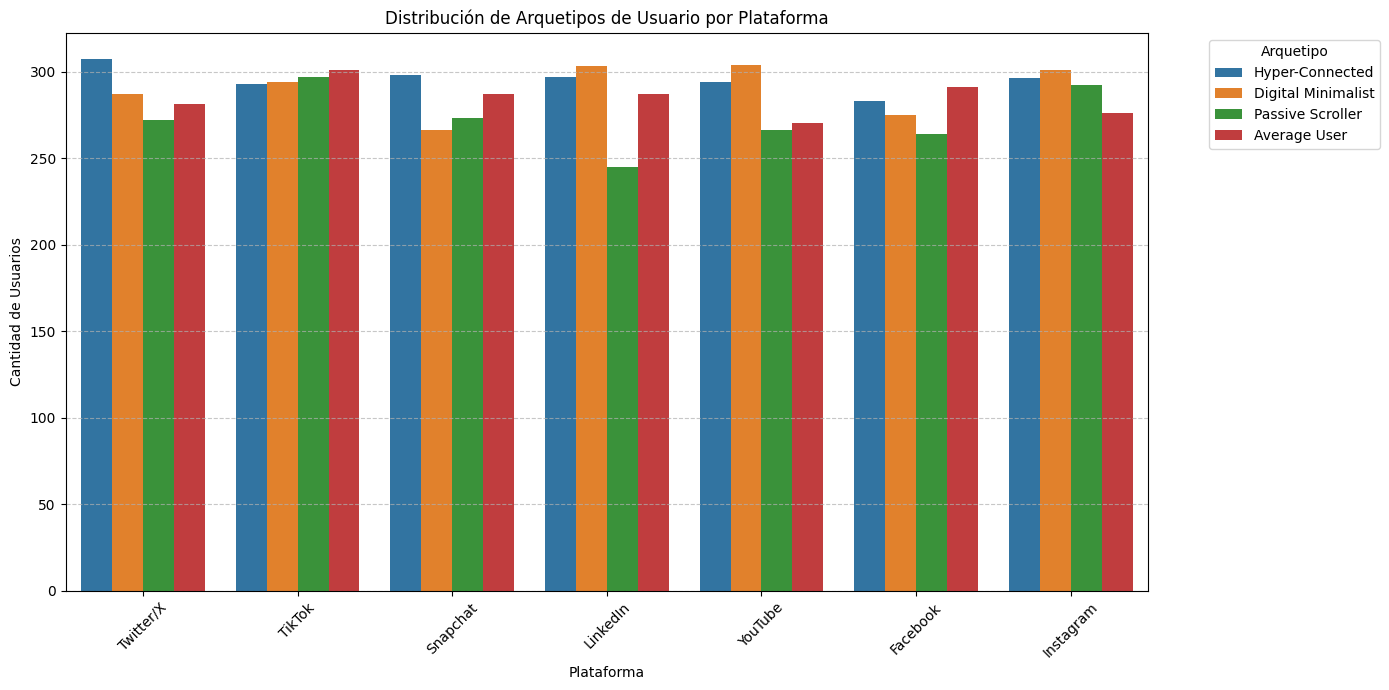

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='primary_platform', hue='user_archetype')
plt.title('Distribución de Arquetipos de Usuario por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Arquetipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Grafico de barras apiladas con la proporcion de cada arquetipo dentro de las principales plataformas.**

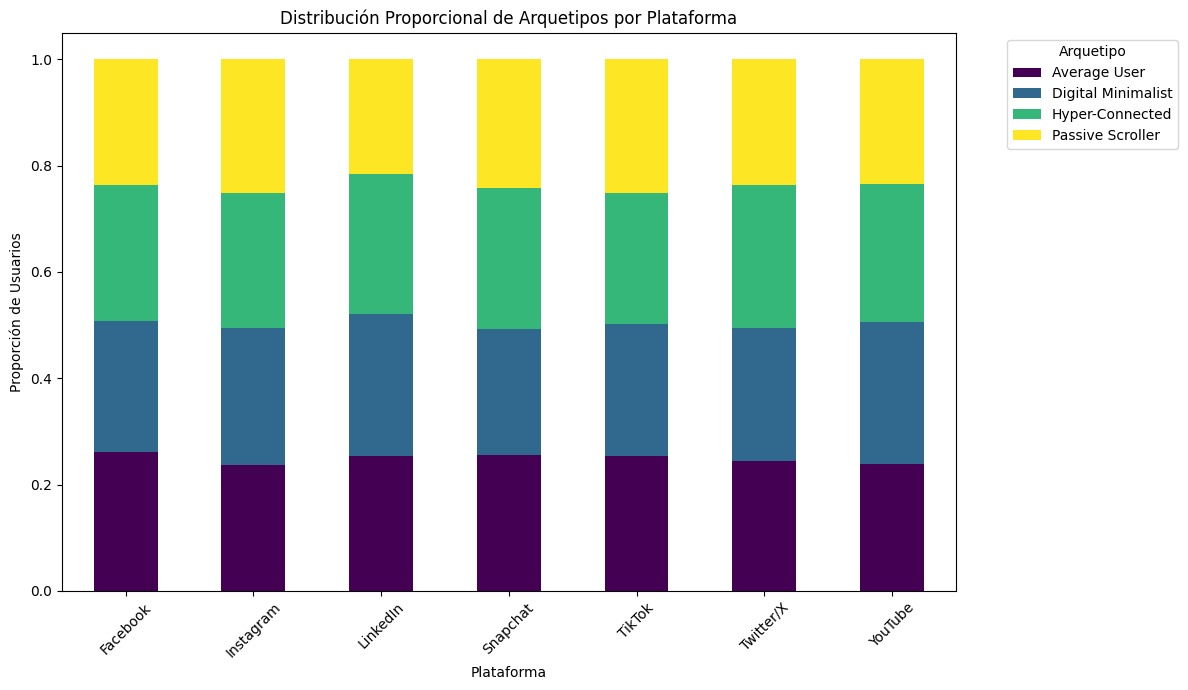

In [ ]:
# Crear una tabla de contingencia normalizada
platform_archetype_dist = pd.crosstab(df['primary_platform'], df['user_archetype'], normalize='index')

# Generar el gráfico de barras apiladas
platform_archetype_dist.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Distribución Proporcional de Arquetipos por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Proporción de Usuarios')
plt.legend(title='Arquetipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'user_archetype', 'primary_platform',
       'daily_screen_time_hours', 'dominant_content_type', 'activity_type',
       'late_night_usage', 'social_comparison_trigger', 'sleep_duration_hours',
       'gad_7_score', 'gad_7_severity', 'phq_9_score', 'phq_9_severity'],
      dtype='object')

**Grafico de dispersion con linea de regresion entre horas diarias de pantalla y horas de sueño.**

In [ ]:
screen_time_sleep_hours = df[['daily_screen_time_hours', 'sleep_duration_hours']]
screen_time_sleep_hours.shape

(8000, 2)

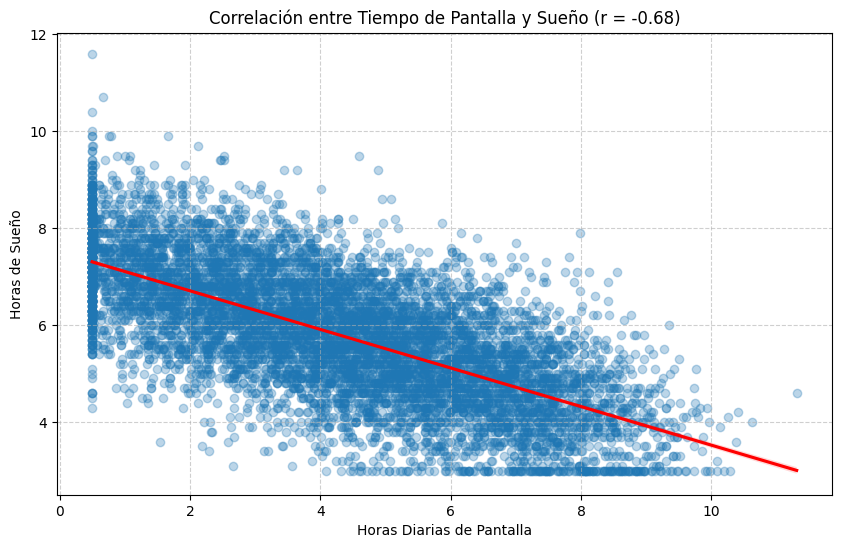

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=screen_time_sleep_hours, x='daily_screen_time_hours', y='sleep_duration_hours',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

correlation = screen_time_sleep_hours['daily_screen_time_hours'].corr(screen_time_sleep_hours['sleep_duration_hours'])

plt.title(f'Correlación entre Tiempo de Pantalla y Sueño (r = {correlation:.2f})')
plt.xlabel('Horas Diarias de Pantalla')
plt.ylabel('Horas de Sueño')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,4028
Male,3972


**Crear un grafico tipo "Dona" con la proporcion de arquetipos para los usuarios masculinos.**

In [ ]:
mask_males = df['gender'] == 'Male'
socials_male = df.loc[mask_males]
socials_male.shape

(3972, 15)

In [ ]:
male_archetypes = pd.DataFrame(socials_male['user_archetype'].value_counts()).reset_index()
male_archetypes['%'] = round((male_archetypes['count'] / male_archetypes['count'].sum()) * 100, 1)
male_archetypes

,user_archetype,count,%
0,Digital Minimalist,1037,26.1
1,Hyper-Connected,997,25.1
2,Passive Scroller,971,24.4
3,Average User,967,24.3


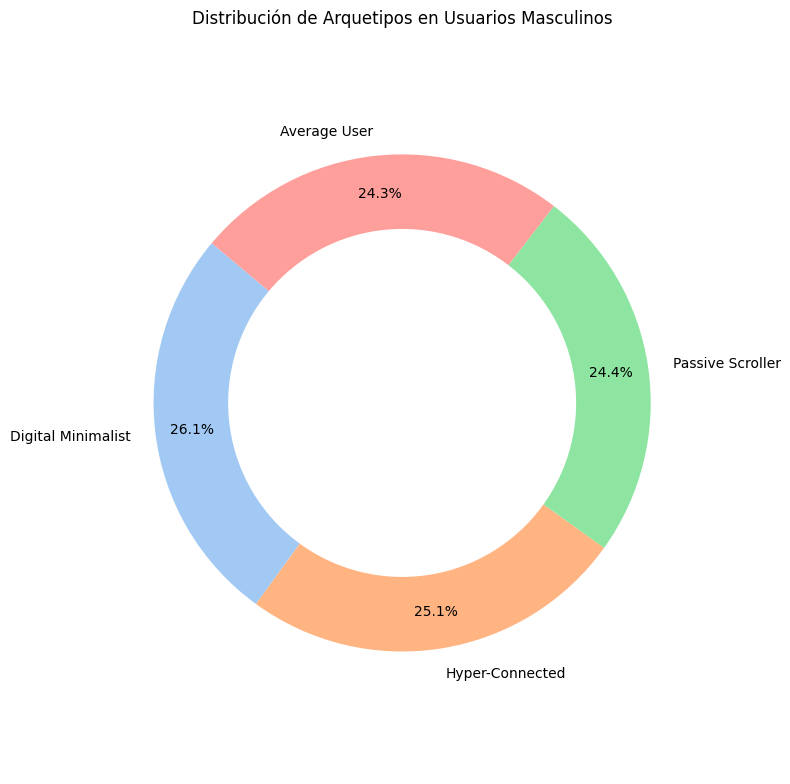

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(male_archetypes['count'], labels=male_archetypes['user_archetype'], autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=sns.color_palette('pastel'))

# Dibujar un círculo blanco en el centro para crear el efecto de dona
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribución de Arquetipos en Usuarios Masculinos')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Crear un grafico de tipo "Dona" con la proporcion de arquetipos para los usuarios femeninos.**

In [ ]:
mask_female = df['gender'] == 'Female'
socials_female = df.loc[mask_female]
socials_female.shape

(4028, 15)

In [ ]:
female_archetypes = pd.DataFrame(socials_female['user_archetype'].value_counts()).reset_index()
female_archetypes['%'] = round(female_archetypes['count'] / female_archetypes['count'].sum() * 100, 1)
female_archetypes.head()

,user_archetype,count,%
0,Hyper-Connected,1071,26.6
1,Average User,1026,25.5
2,Digital Minimalist,993,24.7
3,Passive Scroller,938,23.3


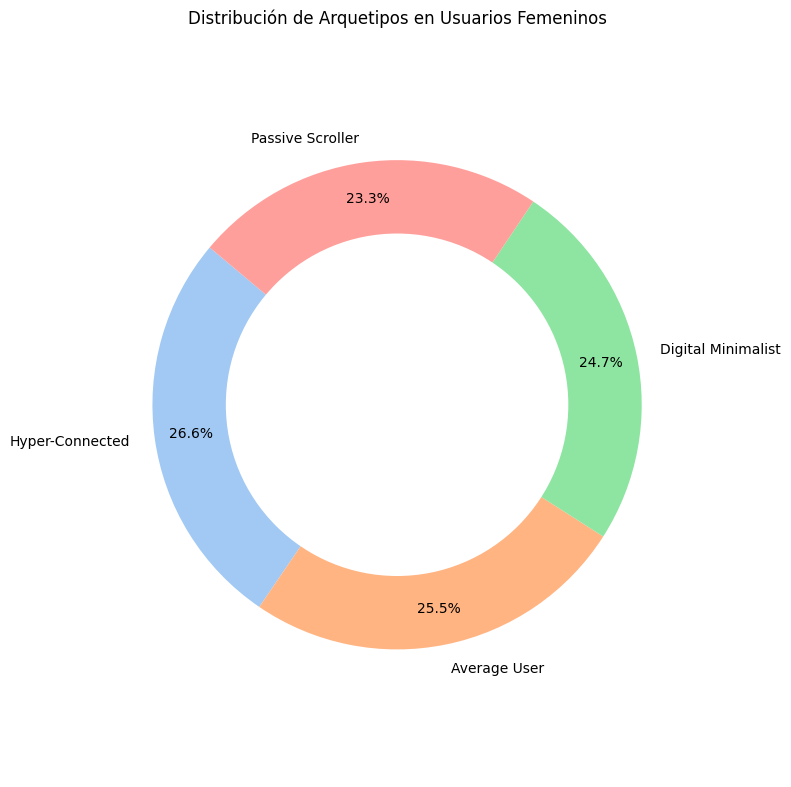

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(female_archetypes['count'], labels=female_archetypes['user_archetype'], autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=sns.color_palette('pastel'))

# Dibujar un círculo blanco en el centro para crear el efecto de dona
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribución de Arquetipos en Usuarios Femeninos')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Grafico de barras agrupado con la distribucion de arquetipos por genero**

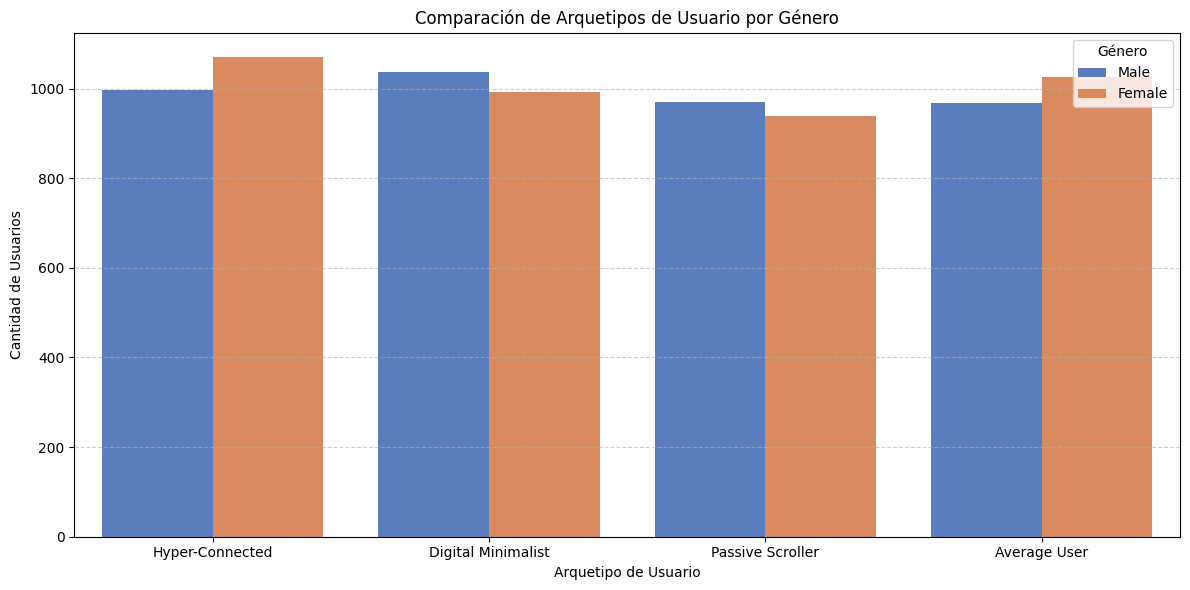

gender,Female,Male
user_archetype,,
Average User,1026,967
Digital Minimalist,993,1037
Hyper-Connected,1071,997
Passive Scroller,938,971


In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='user_archetype', hue='gender', palette='muted')

plt.title('Comparación de Arquetipos de Usuario por Género')
plt.xlabel('Arquetipo de Usuario')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Género')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Mostrar la tabla de frecuencias para mayor precisión
pd.crosstab(df['user_archetype'], df['gender'])

In [ ]:
df.head()

,user_id,age,gender,user_archetype,primary_platform,daily_screen_time_hours,dominant_content_type,activity_type,late_night_usage,social_comparison_trigger,sleep_duration_hours,gad_7_score,gad_7_severity,phq_9_score,phq_9_severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


**Crear un grafico de barras agrupado con la distribucion de las redes sociales por sexo**

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'user_archetype', 'primary_platform',
       'daily_screen_time_hours', 'dominant_content_type', 'activity_type',
       'late_night_usage', 'social_comparison_trigger', 'sleep_duration_hours',
       'gad_7_score', 'gad_7_severity', 'phq_9_score', 'phq_9_severity'],
      dtype='object')

In [ ]:
df['primary_platform'].nunique()

7

In [ ]:
socials_by_sex = df.groupby(['primary_platform', 'gender'])['user_id'].count().reset_index()
socials_by_sex

,primary_platform,gender,user_id
0,Facebook,Female,594
1,Facebook,Male,519
2,Instagram,Female,554
3,Instagram,Male,611
4,LinkedIn,Female,577
5,LinkedIn,Male,555
6,Snapchat,Female,542
7,Snapchat,Male,582
8,TikTok,Female,592
9,TikTok,Male,593


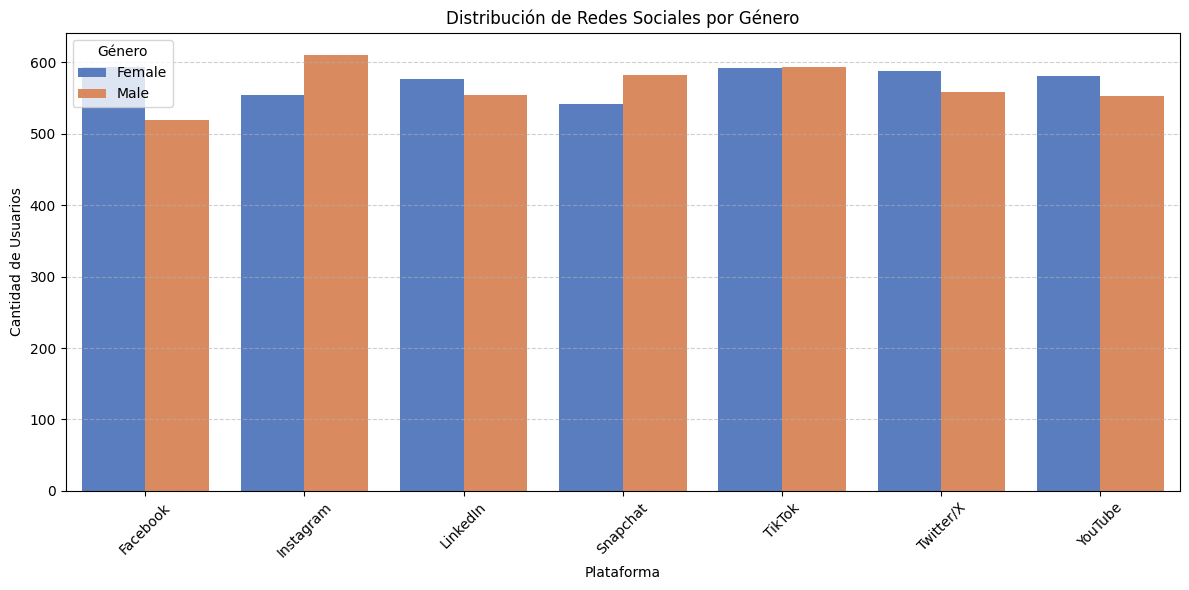

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=socials_by_sex, x='primary_platform', y='user_id', hue='gender', palette='muted')

plt.title('Distribución de Redes Sociales por Género')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de Usuarios')
plt.legend(title='Género')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Comparacion de horas de sueño segun el arquetipo de usuario**

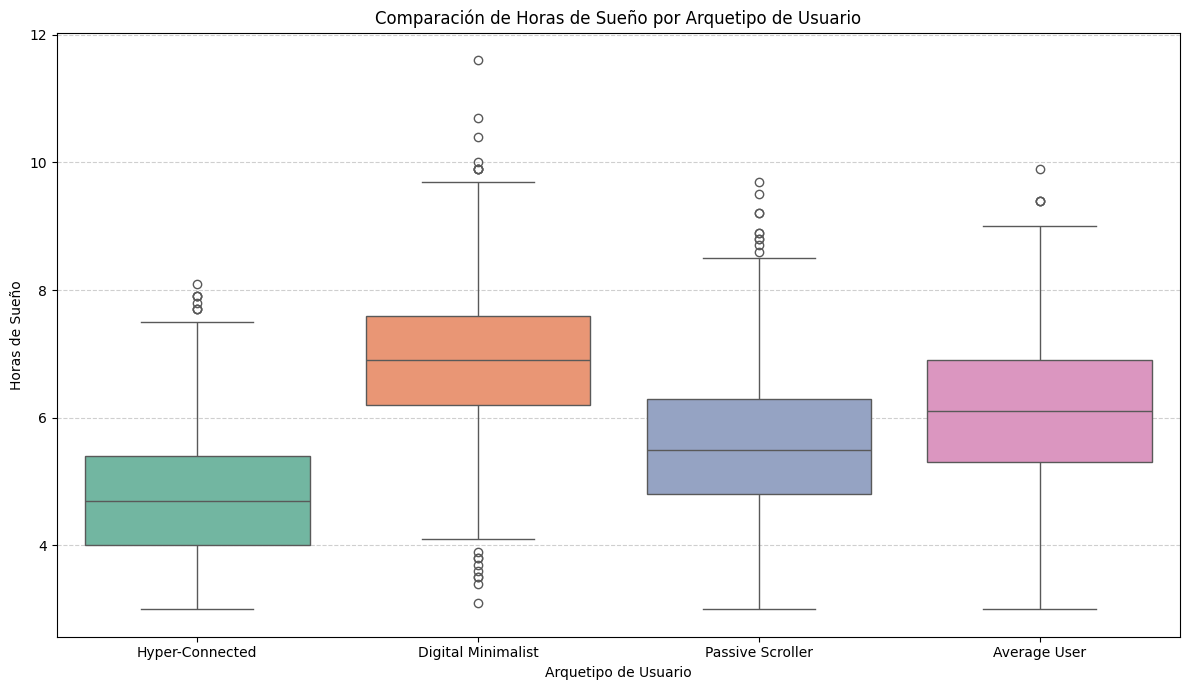

,sleep_duration_hours
user_archetype,
Digital Minimalist,6.896207
Average User,6.103563
Passive Scroller,5.502095
Hyper-Connected,4.718907


In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='user_archetype', hue='user_archetype', y='sleep_duration_hours', palette='Set2')

plt.title('Comparación de Horas de Sueño por Arquetipo de Usuario')
plt.xlabel('Arquetipo de Usuario')
plt.ylabel('Horas de Sueño')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Calculamos también el promedio numérico para referencia
sleep_stats = df.groupby('user_archetype')['sleep_duration_hours'].mean().sort_values(ascending=False)
display(sleep_stats)